**Step 1: Problem Understanding & Framing**

Student attrition continues to be a challenge in higher education institutions, lowering graduation rates, affecting institutional performance, and leading to inefficient use of educational resources. Early identification of at-risk students enables institutions to offer timely interventions including academic advising, financial aid, mentoring, and counselling to increase student retention and success. This project addresses the challenge using the dataset from UCI Machine Learning Repository, which contains demographic, socioeconomic, academic, and enrollment-related information from 4,424 students. The objective is to develop a predictive model that can identify students who are likely to drop out before completing their academic program.


This study considers the problem as a supervised binary classification task to predict whether a student is at risk of dropout (Dropout) or not (Graduate), while excluding students whose academic status is still Enrolled. Several  machine learning classification algorithms will be developed and analyzed to determine the model that best predicts the risk of student dropout. The primary evaluation metric will be the AUC-ROC (target: ≥ 0.80) since it measures the model’s ability to discriminate between at-risk and non-at-risk students across multiple classification thresholds. Recall will serve as the secondary metric since correctly identifying students who are likely to drop out is more important than minimizing false alarms, while Accuracy, Precision, and F1-score will also be reported for comprehensive evaluation. The project's business KPI is to improve the early identification of at-risk students, enabling educational institutions to implement timely interventions that contribute to higher student retention and graduation rates.

**Step 2. Data Collection and Understanding**

In [6]:
!pip3 install -U ucimlrepo

In [7]:

from ucimlrepo import fetch_ucirepo

# fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# data (as pandas dataframes)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

# metadata
print(predict_students_dropout_and_academic_success.metadata)

# variable information
print(predict_students_dropout_and_academic_success.variables)


{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

In [8]:
import pandas as pd

# Load the dataset
df = pd.read_csv("student_dropout_data.csv", sep=None, engine="python")

# Remove hidden characters from column names
df.columns = df.columns.str.replace('\ufeff','').str.strip()

print("========== DATASET OVERVIEW ==========")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Predictor Variables: {df.shape[1]-1}")
print(f"Target Variable: {df.columns[-1]}")

print("\n========== FEATURE TYPES ==========\n")

feature_types = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.values
})

print(feature_types)

print("\n========== MISSING VALUES ==========\n")

missing = pd.DataFrame({
    "Variable": df.columns,
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

print(missing)

print("\n========== DUPLICATE RECORDS ==========\n")

duplicates = df.duplicated().sum()
print(f"Number of duplicate records: {duplicates}")

print(df.describe())

numeric = df.select_dtypes(include=["int64","float64"])

outlier_summary = []

for col in numeric.columns:

    Q1 = numeric[col].quantile(.25)
    Q3 = numeric[col].quantile(.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = ((numeric[col] < lower) |
                (numeric[col] > upper)).sum()

    outlier_summary.append([col,outliers])

outliers = pd.DataFrame(outlier_summary,
                        columns=["Variable","Number of Outliers"])

print(outliers)

print(df["Target"].value_counts())


========== DATASET OVERVIEW ==========
Rows: 4424
Columns: 37
Predictor Variables: 36
Target Variable: Target

========== FEATURE TYPES ==========

                                          Variable Data Type
0                                   Marital status     int64
1                                 Application mode     int64
2                                Application order     int64
3                                           Course     int64
4                       Daytime/evening attendance     int64
5                           Previous qualification     int64
6                   Previous qualification (grade)   float64
7                                      Nacionality     int64
8                           Mother's qualification     int64
9                           Father's qualification     int64
10                             Mother's occupation     int64
11                             Father's occupation     int64
12                                 Admission grade   float6

## Data Dictionary

In [9]:
# Get variable information from the UCI dataset metadata
uci_variables = predict_students_dropout_and_academic_success.variables

# Create lookup dictionaries
description_map = dict(zip(uci_variables["name"], uci_variables["description"]))
type_map = dict(zip(uci_variables["name"], uci_variables["type"]))

# Allowed values and notes (customized based on your data dictionary)
allowed_values = {
    "Marital status": "1=Single, 2=Married, 3=Widower, 4=Divorced, 5=Facto union, 6=Legally separated",
    "Gender": "0=Female, 1=Male",
    "Scholarship holder": "0=No, 1=Yes",
    "Debtor": "0=No, 1=Yes",
    "Tuition fees up to date": "0=No, 1=Yes",
    "Target": "Dropout, Graduate, Enrolled"
}

notes = {
    "Marital status": "Demographic variable",
    "Application mode": "Admission information",
    "Application order": "Enrollment information",
    "Course": "Academic program",
    "Gender": "Demographic variable",
    "Scholarship holder": "Financial support",
    "Debtor": "Financial factor",
    "Target": "Target variable"
}

# Build the data dictionary
dictionary_rows = []

for column in df.columns:
    dictionary_rows.append({
        "Variable Name": column,
        "Type": str(df[column].dtype),
        "Description": description_map.get(column, ""),
        "Allowed Values / Units": allowed_values.get(column, "-"),
        "Notes": notes.get(column, "-")
    })

data_dictionary = pd.DataFrame(dictionary_rows)

# Display the table with a label
print("Data Dictionary:")
display(data_dictionary)

Data Dictionary:


,Variable Name,Type,Description,Allowed Values / Units,Notes
0,Marital status,int64,,"1=Single, 2=Married, 3=Widower, 4=Divorced, 5=...",Demographic variable
1,Application mode,int64,1 - 1st phase - general contingent 2 - Ordinan...,-,Admission information
2,Application order,int64,Application order (between 0 - first choice; a...,-,Enrollment information
3,Course,int64,33 - Biofuel Production Technologies 171 - Ani...,-,Academic program
4,Daytime/evening attendance,int64,1 – daytime 0 - evening,-,-
5,Previous qualification,int64,1 - Secondary education 2 - Higher education -...,-,-
6,Previous qualification (grade),float64,Grade of previous qualification (between 0 and...,-,-
7,Nacionality,int64,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...,-,-
8,Mother's qualification,int64,1 - Secondary Education - 12th Year of Schooli...,-,-
9,Father's qualification,int64,1 - Secondary Education - 12th Year of Schooli...,-,-


The dataset contains 4,424 student records and 37 variables, composed of 36 predictor variables and 1 target variable. Initial Python inspection shows that the dataset has no missing values and no duplicate records. The target variable contains three classes: Graduate (2,209), Dropout (1,421), and Enrolled (794). The predictor variables represent a combination of demographic, academic, financial, family background, and macroeconomic factors that may influence a student's academic outcome. The target variable has three classes: Dropout, Graduate, and Enrolled. For the purposes of this capstone project, the classification problem will focus on distinguishing students who drop out from those who graduate, while records labeled Enrolled may be excluded to create a binary classification model.

Initial data exploration using Python indicated that the dataset is of high quality and suitable for machine learning. The dataset contains no missing values and no duplicate records, reducing the need for extensive data cleaning. The variables consist of a mixture of categorical, binary, integer, and continuous numerical features, providing a comprehensive representation of student characteristics and academic performance. Preliminary descriptive statistics and outlier analysis suggest that some numerical variables, such as Age at Enrollment, Admission Grade, and semester academic performance variables, contain extreme values. However, these observations likely reflect genuine differences among students rather than data errors and will be evaluated further during the preprocessing stage. Overall, the dataset appropriate for developing and evaluating machine learning models for predicting student dropout risk.


**Step 3: Data Preprocessing, Applied EDA & Feature Engineering**

In [10]:
# Data Cleaning

# Check missing values
df.isnull().sum()

# Check duplicate records
df_ml = df.copy() # Initialize df_ml from df
df_ml.duplicated().sum()
df_ml = df_ml.drop_duplicates()

# Convert the target variable into binary classification
df_ml = df_ml[df_ml["Target"].isin(["Dropout", "Graduate"])]

df_ml["Target"] = df_ml["Target"].map({
    "Graduate": 0,
    "Dropout": 1
})

# Detect Outliers
numeric_cols = df_ml.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df_ml[col].quantile(0.25)
    Q3 = df_ml[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_ml[col] < lower) | (df_ml[col] > upper)).sum()
    outlier_summary.append([col, outliers])

outlier_df = pd.DataFrame(outlier_summary, columns=["Variable", "Number of Outliers"])
outlier_df



,Variable,Number of Outliers
0,Marital status,431
1,Application mode,0
2,Application order,468
3,Course,381
4,Daytime/evening attendance,408
5,Previous qualification,611
6,Previous qualification (grade),146
7,Nacionality,86
8,Mother's qualification,0
9,Father's qualification,0


Data cleaning was performed to ensure that the dataset was accurate, consistent, and suitable for machine learning analysis. The dataset was first examined for missing values and duplicate records to identify any issues that could affect model performance. The results showed that the dataset contained no missing values and no duplicate observations; therefore, no imputation or record removal was necessary. Outlier detection was conducted using the Interquartile Range (IQR) method to identify extreme values in numerical variables. Although outliers were detected in variables such as Age at Enrollment, Admission Grade, and semester academic performance indicators, these observations were retained because they likely represent genuine differences among students rather than data entry errors. Retaining these values preserves important information that may contribute to accurately predicting student dropout risk.

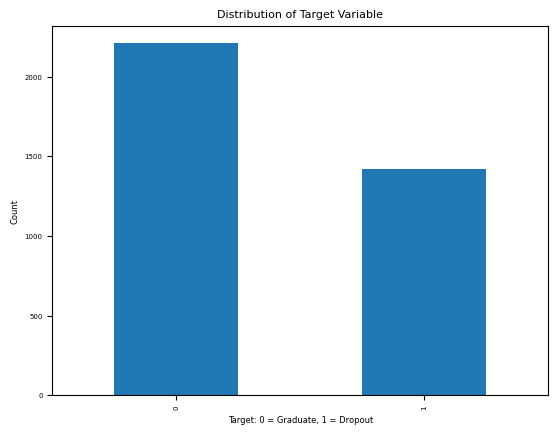

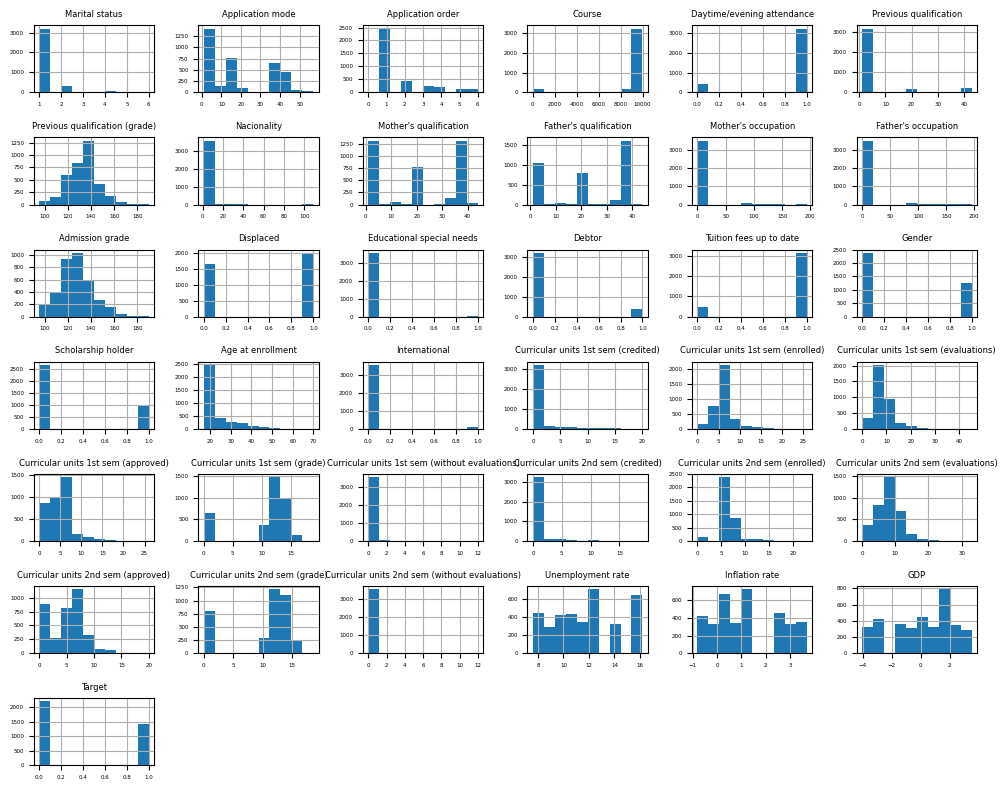

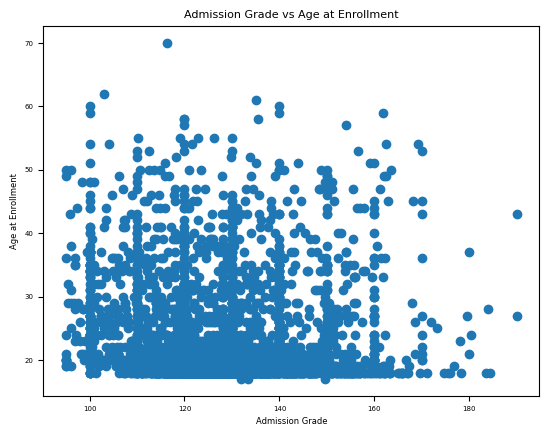

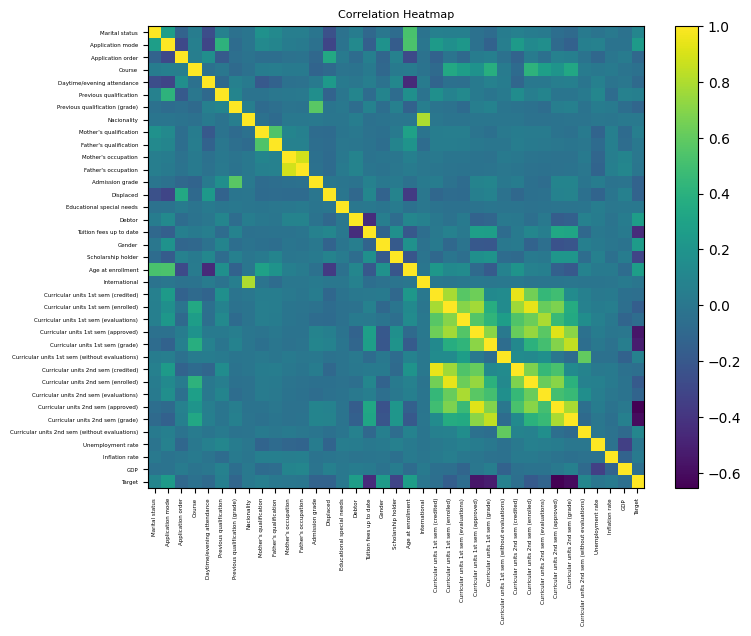

In [11]:
import matplotlib.pyplot as plt

# Apply Exploratory Data Analysis (EDA)
# Analyzing Target Distribution
df_ml["Target"].value_counts().plot(kind="bar")
plt.title("Distribution of Target Variable", fontsize=8) # Smaller font
plt.xlabel("Target: 0 = Graduate, 1 = Dropout", fontsize=6) # Smaller font
plt.ylabel("Count", fontsize=6) # Smaller font
plt.xticks(fontsize=5) # Smaller font
plt.yticks(fontsize=5) # Smaller font
plt.show()

#Analyze Feature Distribution
fig_hist = df_ml[numeric_cols].hist(figsize=(10, 8))
for ax_row in fig_hist:
    for ax in ax_row:
        ax.title.set_fontsize(6) # Smaller font for subplot titles
        ax.xaxis.label.set_fontsize(5) # Smaller font for x-labels
        ax.yaxis.label.set_fontsize(5) # Smaller font for y-labels
        ax.tick_params(axis='x', labelsize=4) # Smaller font for x-tick labels
        ax.tick_params(axis='y', labelsize=4) # Smaller font for y-tick labels
plt.tight_layout()
plt.show()

#Analyze relationship between variables

plt.scatter(df_ml["Admission grade"], df_ml["Age at enrollment"])
plt.xlabel("Admission Grade", fontsize=6) # Smaller font
plt.ylabel("Age at Enrollment", fontsize=6) # Smaller font
plt.title("Admission Grade vs Age at Enrollment", fontsize=8) # Smaller font
plt.xticks(fontsize=5) # Smaller font
plt.yticks(fontsize=5) # Smaller font
plt.show()

# Correlation Analysis
corr = df_ml.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Heatmap", fontsize=8) # Smaller font
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=4) # Smaller font
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=4) # Smaller font
plt.show()

In [12]:
# Feature Engineering
# Separate features and target
X = df_ml.drop("Target", axis=1)
y = df_ml["Target"]

# Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Scale numerical features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Create domain derived features
X_encoded["Total approved units"] = (
    df_ml["Curricular units 1st sem (approved)"] + # Corrected column name
    df_ml["Curricular units 2nd sem (approved)"] # Corrected column name
)

X_encoded["Average semester grade"] = (
    df_ml["Curricular units 1st sem (grade)"] + # Corrected column name
    df_ml["Curricular units 2nd sem (grade)"] # Corrected column name
) / 2

Feature engineering was performed to transform the dataset into a format that is more suitable for machine learning algorithms. Since the objective of the study is to predict student dropout risk, the original three-class target variable was converted into a binary classification problem by retaining only the Dropout and Graduate classes and excluding students whose status remained Enrolled. Categorical variables were encoded into numerical representations to enable their use in machine learning models, while numerical features were standardized using the StandardScaler to ensure that variables measured on different scales contributed equally during model training. In addition, domain-derived features, such as the Total Approved Units and Average Semester Grade, were created to better represent students' overall academic performance, which is expected to be a strong predictor of dropout.

In [13]:
# Feature selection
# Use SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X_encoded, y)

selected_features = X_encoded.columns[selector.get_support()]
selected_features

Index(['Application mode', 'Admission grade', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)', 'Total approved units',
       'Average semester grade'],
      dtype='object')

Feature selection was performed to identify the variables that contribute most significantly to predicting student dropout. The SelectKBest method, using the ANOVA F-test, was applied to rank predictor variables according to their statistical relationship with the target variable. Selecting only the most relevant features helps reduce model complexity, minimizes the influence of irrelevant or redundant variables, improves computational efficiency, and enhances the interpretability of the resulting machine learning models.

SelectKBest was chosen because it is a simple, effective filter-based feature selection method that ranks features based on their statistical relationship with the target variable. It reduces dimensionality, removes less informative features, and improves model performance while lowering computational cost. Compared with wrapper methods, it is much faster and model-independent, making it suitable for an initial feature selection stage.

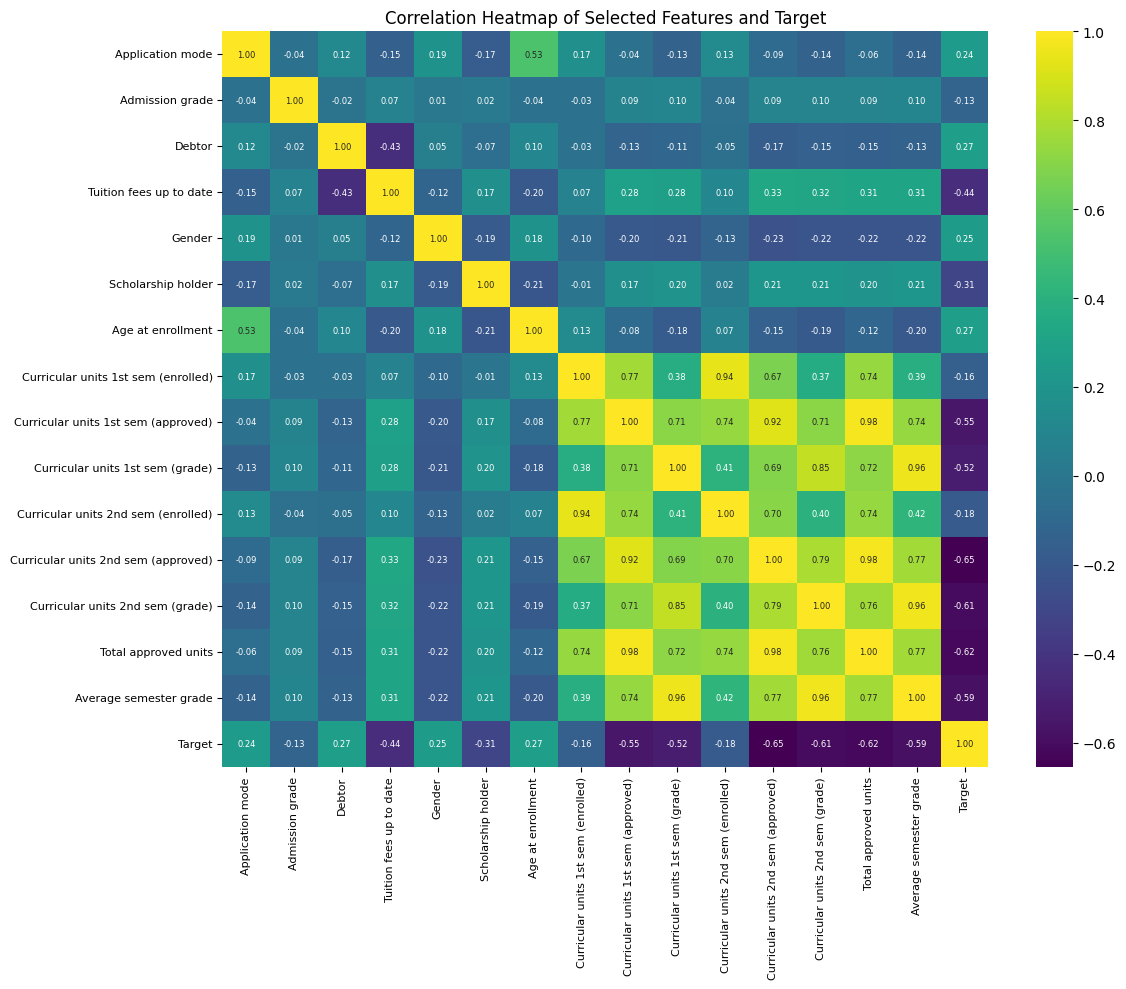

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine selected features with the target variable for correlation calculation
# Need to ensure 'Total approved units' and 'Average semester grade' are in the DataFrame
# X_encoded already has these, so let's use a subset of X_encoded and y

# First, identify which of the 'selected_features' are from X_encoded and are numeric
# The selected_features from SelectKBest might contain original as well as the derived features
# We will reconstruct a DataFrame for correlation.

# Get the DataFrame with selected features and add the target
df_selected_features_corr = X_encoded[selected_features].copy()

# y is already a Series of 0s and 1s, so we can assign it directly
df_selected_features_corr['Target'] = y.copy()

# Calculate the correlation matrix
corr_selected = df_selected_features_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_selected, annot=True, cmap='viridis', fmt=".2f", annot_kws={"fontsize": 6})
plt.title('Correlation Heatmap of Selected Features and Target', fontsize=12)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_763/550611692.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=feature, data=df_for_boxplots, palette='viridis')
/tmp/ipykernel_763/550611692.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=feature, data=df_for_boxplots, palette='viridis')
/tmp/ipykernel_763/550611692.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=feature, data=df_for_boxplots, palette='viridis')
/tmp/ipykernel_763/550611692.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

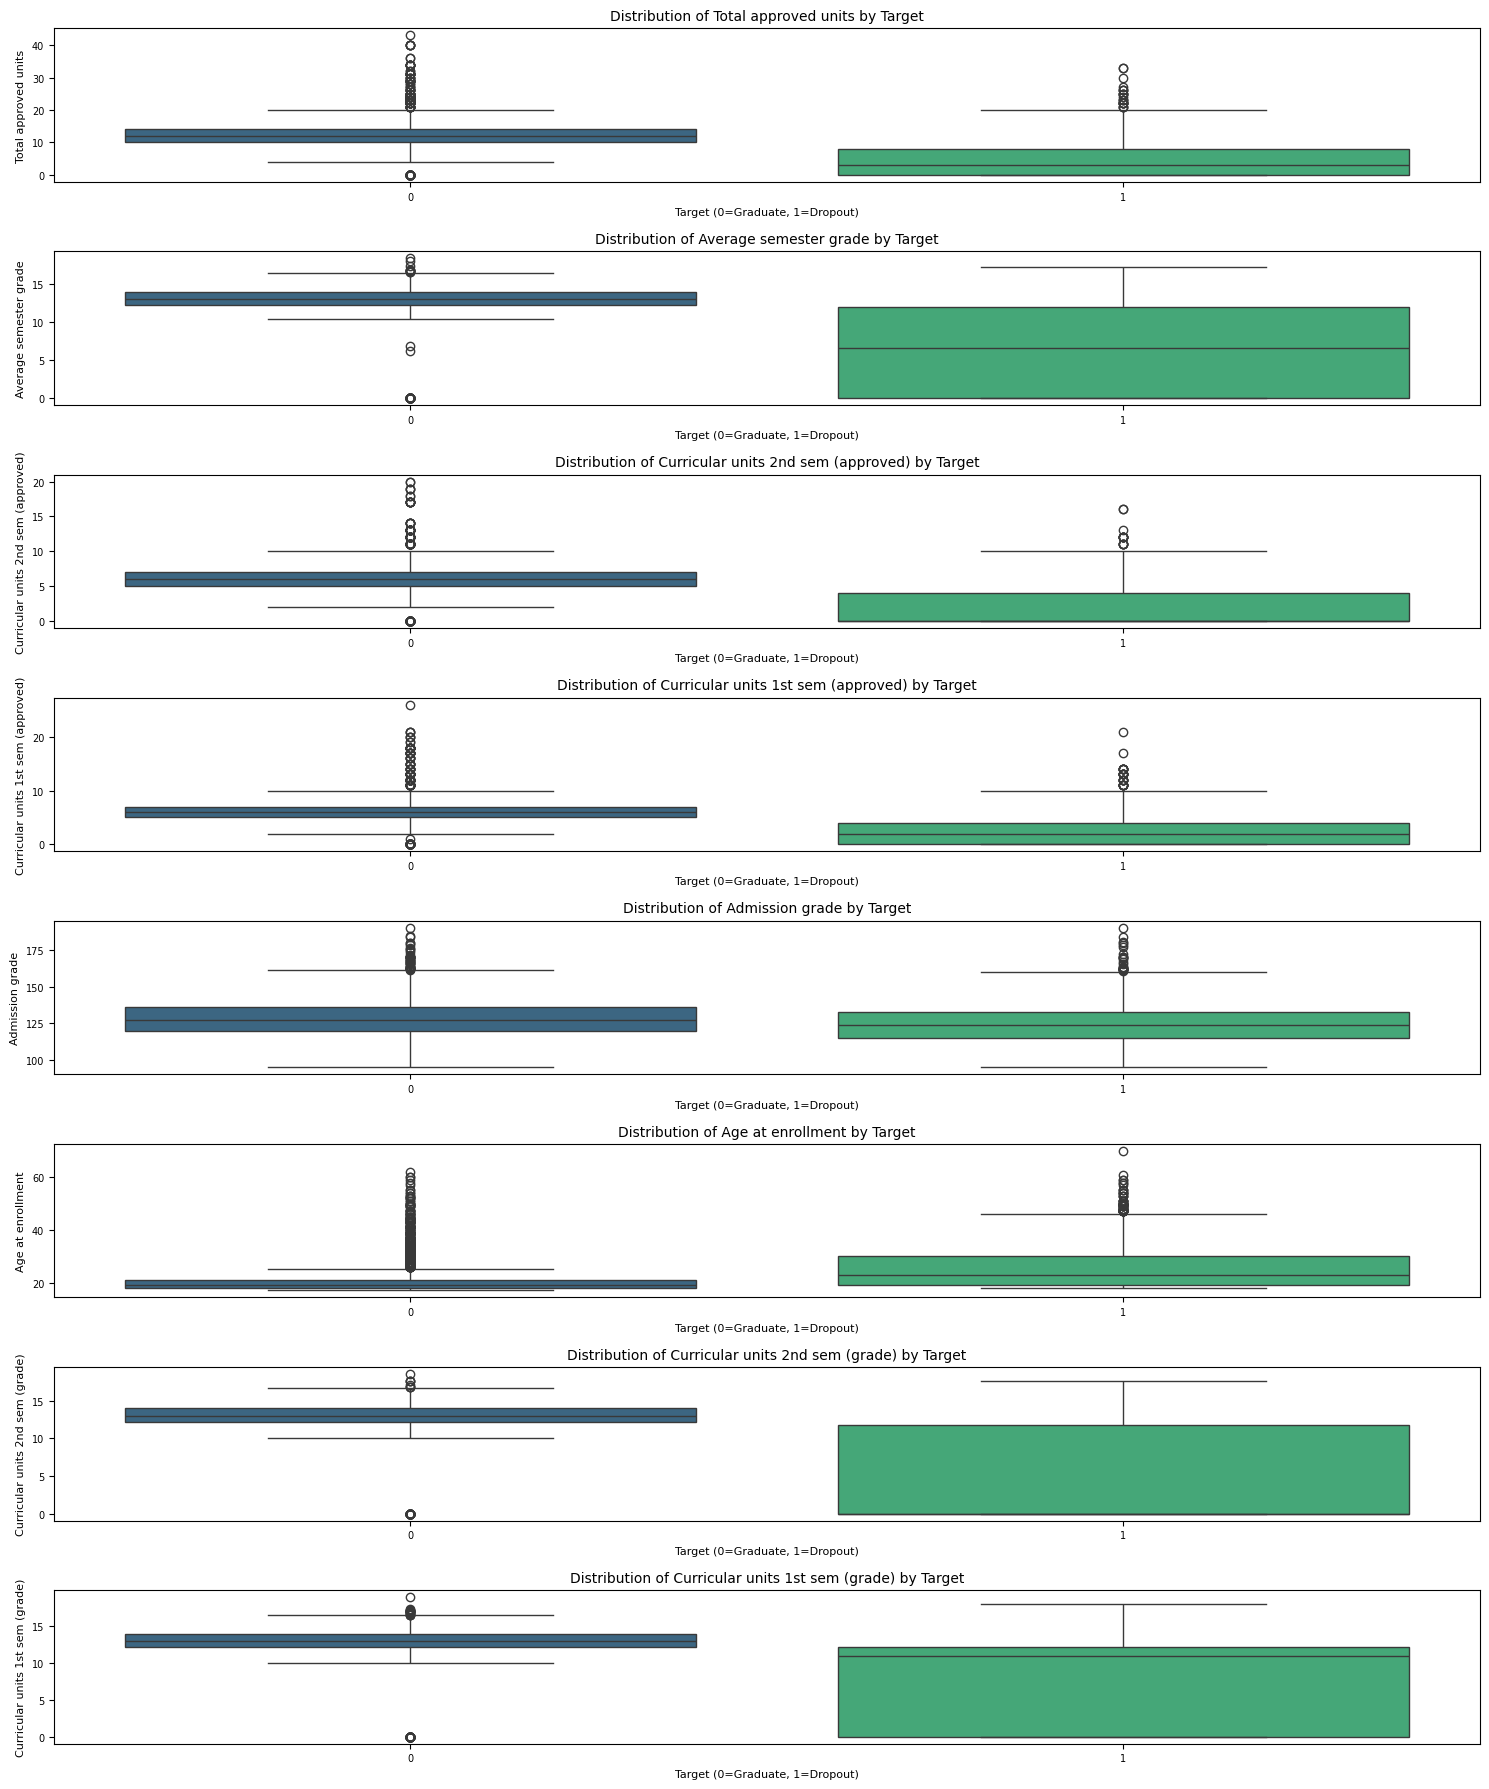

In [15]:
# Select a few important numerical features for boxplots
# Based on the feature importance analysis, let's pick some top ones that are numerical
# And include the derived features 'Total approved units' and 'Average semester grade'

important_numerical_features = [
    'Total approved units',
    'Average semester grade',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (approved)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (grade)'
]

# Ensure these features exist in X_encoded (where they were created or encoded)
# Create a temporary DataFrame for plotting
df_for_boxplots = X_encoded[important_numerical_features].copy()
df_for_boxplots['Target'] = y

plt.figure(figsize=(15, 18))
for i, feature in enumerate(important_numerical_features):
    plt.subplot(len(important_numerical_features), 1, i + 1) # One row per feature
    sns.boxplot(x='Target', y=feature, data=df_for_boxplots, palette='viridis')
    plt.title(f'Distribution of {feature} by Target', fontsize=10)
    plt.xlabel('Target (0=Graduate, 1=Dropout)', fontsize=8)
    plt.ylabel(feature, fontsize=8)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

EDA was conducted to better understand the characteristics of the dataset and identify patterns that may influence student dropout. The distribution of the target variable was examined to assess the balance between dropout and graduate cases, while histograms were used to explore the distribution of numerical variables and identify potential skewness or unusual patterns. Scatter plots and correlation analysis were also performed to investigate relationships among predictor variables and determine which factors may be associated with student dropout. These analyses provided valuable insights into the structure of the data and informed subsequent preprocessing and feature engineering decisions.



A Correlation Heatmap of Selected Features and Target was made to visualize the relationships between the important features and the target variable. To further understand how important features differ between 'Graduate' (0) and 'Dropout' (1) students, let's create boxplots for some of the top numerical features. This will visually represent the distribution of these features across the two target classes.

[0.18025544 0.10320944]


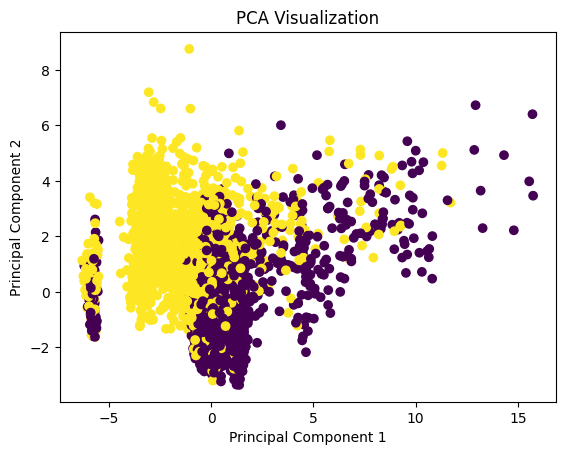

In [16]:
# Dimensionality Reduction
# Apply PCA and visualize results
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()


Principal Component Analysis (PCA) was applied as a dimensionality reduction technique to transform the high-dimensional feature space into a smaller set of principal components while preserving most of the variability in the data. This approach simplifies the dataset, reduces computational requirements, and enables visualization of the overall data structure in two dimensions. PCA also helps identify whether natural separation exists between students who graduate and those who drop out, providing additional insight into the underlying patterns within the dataset.

In [17]:
# Feature Importance and Explainability
# Train model for feature imjportance and display feature importance
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_encoded, y)

importance_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
36,Total approved units,0.166784
30,Curricular units 2nd sem (approved),0.156072
24,Curricular units 1st sem (approved),0.091018
31,Curricular units 2nd sem (grade),0.077530
37,Average semester grade,0.071256
25,Curricular units 1st sem (grade),0.045186
16,Tuition fees up to date,0.044036
12,Admission grade,0.026141
19,Age at enrollment,0.024359
29,Curricular units 2nd sem (evaluations),0.023649


Feature importance analysis was conducted using a Random Forest classifier to determine which variables have the greatest influence on predicting student dropout. This model-based approach provides an interpretable ranking of predictor variables based on their contribution to the classification process. Understanding feature importance improves the transparency of the predictive model and helps identify the academic, demographic, and financial factors that are most strongly associated with student dropout. These insights can support educational institutions in designing targeted intervention strategies for students who are identified as being at risk.

**Step 4: Model Implementation**

In [18]:
# Prepare training data for testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train baseline models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

log_model = LogisticRegression(max_iter=1000, random_state=42)
tree_model = DecisionTreeClassifier(random_state=42)

log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

# Train ensemble models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Evaluate models using the same metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

model_comparison = pd.DataFrame(results)
model_comparison

# Use cross-validation
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_encoded, y, cv=5, scoring="roc_auc")
    print(name, "Mean AUC:", scores.mean())

# Tune the besgt performing model
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
grid_search.best_params_

# Evaluate tuned model
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

best_results = {
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1 Score": f1_score(y_test, y_pred_best),
    "AUC": roc_auc_score(y_test, y_prob_best)
}

best_results

# Save trained model
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/student_dropout_best_model.pkl")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression Mean AUC: 0.9452350790727803
Decision Tree Mean AUC: 0.8538112009738985
Random Forest Mean AUC: 0.9536107976482111
Gradient Boosting Mean AUC: 0.9555790036770191


['models/student_dropout_best_model.pkl']

For step 4, several machine learning models were implemented and evaluated to identify the most effective algorithm for predicting student dropout risk. The models included Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Their predictive performance was assessed using multiple evaluation metrics, namely Accuracy, Precision, Recall, F1 Score, and the Area Under the Receiver Operating Characteristic Curve (AUC), to provide a comprehensive comparison of their classification capabilities. To ensure that the models generalized well to unseen data, k-fold cross-validation was performed. The results showed that the Random Forest and Gradient Boosting models achieved the highest mean AUC scores, indicating superior predictive performance and robustness.

Following the initial evaluation, the Random Forest model was selected for further optimization through hyperparameter tuning using GridSearchCV. This process identified the optimal combination of parameters, resulting in an improved model that achieved an AUC of approximately 0.972. The best-performing model was then saved as to ensure reproducibility and facilitate future deployment.

**Step 5: Critical Thinking → Ethical AI & Bias Auditing**

In [19]:
!pip install shap

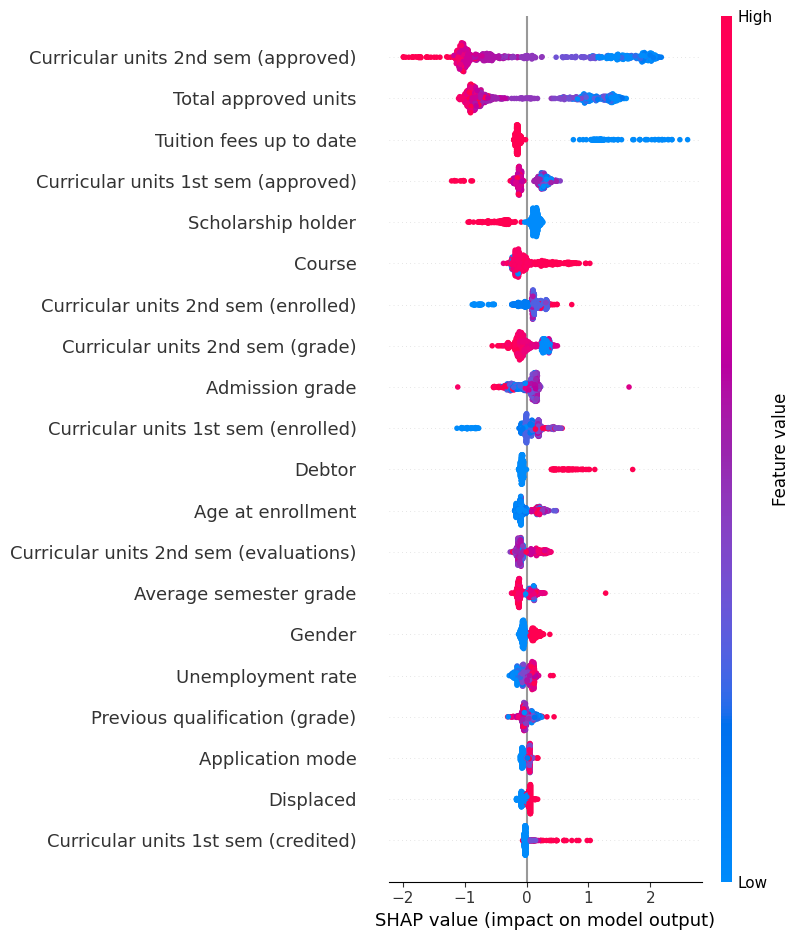

SHAP values calculated successfully.


In [20]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

# Assuming `best_model` is your tuned RandomForestClassifier
# and `X_train` is the preprocessed training data

# Create a SHAP explainer object
# For tree-based models, TreeExplainer is efficient
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for the test set
# Using a subset of X_test for faster computation and visualization if X_test is very large
# Here, we'll use a sample to keep plots manageable
X_test_sample = X_test.sample(n=100, random_state=42) # Adjust sample size as needed
shap_values = explainer.shap_values(X_test_sample)

# If it's a binary classification, shap_values will often be a list of two arrays (for class 0 and class 1)
# or a 3D array of shape (samples, features, classes).
# We usually look at the SHAP values for the positive class (class 1 for Dropout).
# The following line is adjusted to handle both typical outputs of TreeExplainer.
if isinstance(shap_values, list):
    # If shap_values is a list of arrays (e.g., [shap_class_0, shap_class_1])
    shap_values_for_class_1 = shap_values[1]
else:
    # If shap_values is a 3D array (e.g., (samples, features, classes))
    shap_values_for_class_1 = shap_values[:, :, 1]

print("SHAP values calculated successfully.")

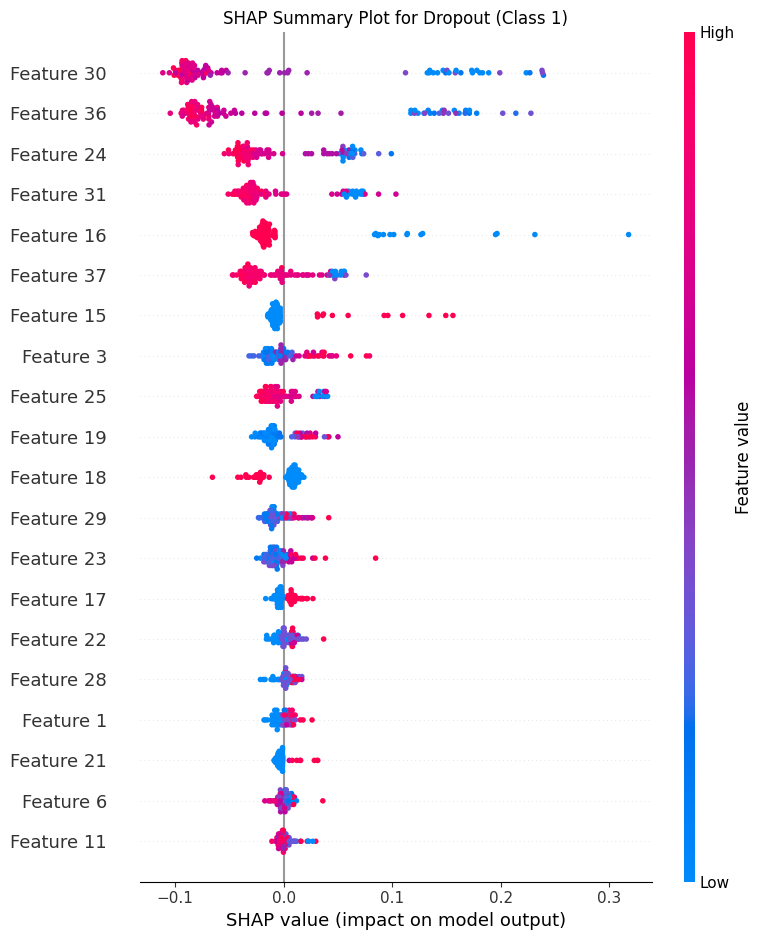

In [21]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_for_class_1, X_test_sample.values, plot_type="dot", show=False)
plt.title('SHAP Summary Plot for Dropout (Class 1)', fontsize=12) # Reduced title font size
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

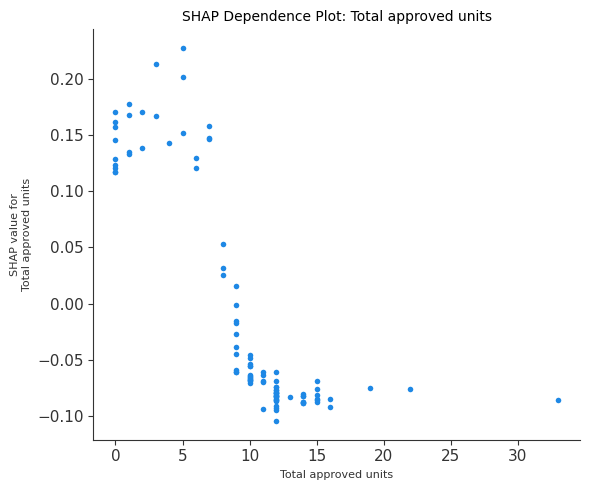

<Figure size 800x600 with 0 Axes>

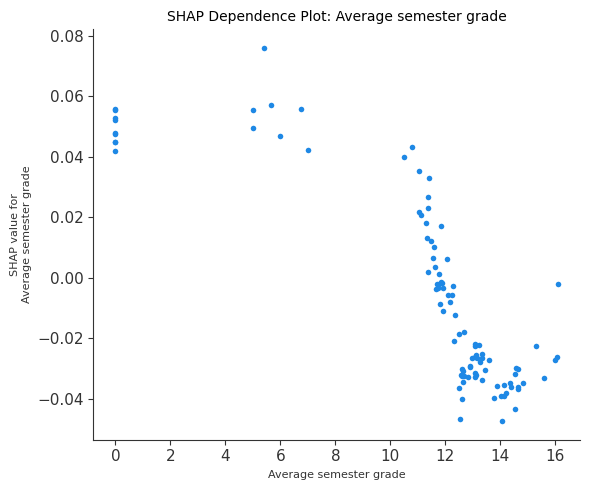

In [22]:
# Choose a few important features from the summary plot for detailed dependence plots
# Example: 'Total approved units' and 'Average semester grade'

# Feature 1: Total approved units
plt.figure(figsize=(8, 6))
shap.dependence_plot(
    "Total approved units",
    shap_values_for_class_1,
    X_test_sample.values,
    feature_names=X_test_sample.columns,
    interaction_index=None, # Show interaction with another feature if desired
    show=False
)
plt.title('SHAP Dependence Plot: Total approved units', fontsize=10) # Reduced title font size
plt.xlabel('Total approved units', fontsize=8) # Added x-label font size
plt.ylabel('SHAP value for\nTotal approved units', fontsize=8) # Added y-label font size
plt.tight_layout()
plt.show()

# Feature 2: Average semester grade
plt.figure(figsize=(8, 6))
shap.dependence_plot(
    "Average semester grade",
    shap_values_for_class_1,
    X_test_sample.values,
    feature_names=X_test_sample.columns,
    interaction_index=None,
    show=False
)
plt.title('SHAP Dependence Plot: Average semester grade', fontsize=10) # Reduced title font size
plt.xlabel('Average semester grade', fontsize=8) # Added x-label font size
plt.ylabel('SHAP value for\nAverage semester grade', fontsize=8) # Added y-label font size
plt.tight_layout()
plt.show()

In [23]:
# Create a DataFrame for fairness analysis
gender_test = X_test["Gender"]

fairness_df = pd.DataFrame({
    "Gender": gender_test,
    "Actual": y_test,
    "Prediction": y_pred
})

fairness_df.head()
display(fairness_df.head())

#  Demographic parity
parity = fairness_df.groupby("Gender")["Prediction"].mean()

print(parity)

# Equalized odds
from sklearn.metrics import recall_score

for gender in fairness_df["Gender"].unique():

    mask = fairness_df["Gender"] == gender

    recall = recall_score(
        fairness_df.loc[mask, "Actual"],
        fairness_df.loc[mask, "Prediction"]
    )

    print(f"Gender {gender}: Recall = {recall:.3f}")

# Disparate impact
positive_rates = fairness_df.groupby("Gender")["Prediction"].mean()

di = positive_rates.min() / positive_rates.max()

print(f"Disparate Impact = {di:.3f}")



,Gender,Actual,Prediction
3622,0,0,0
4325,0,0,0
1558,1,1,0
3458,0,0,0
4291,1,0,1


Gender
0    0.287671
1    0.517361
Name: Prediction, dtype: float64
Gender 0: Recall = 0.900
Gender 1: Recall = 0.890
Disparate Impact = 0.556


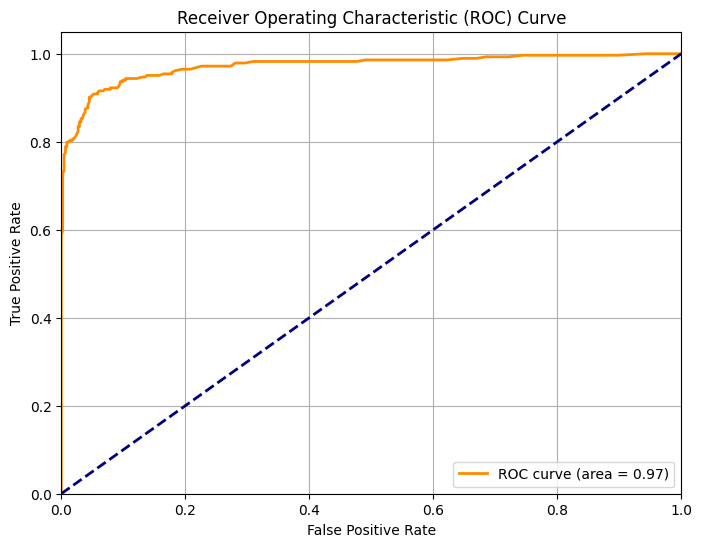

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC for the best model
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

<Figure size 800x600 with 0 Axes>

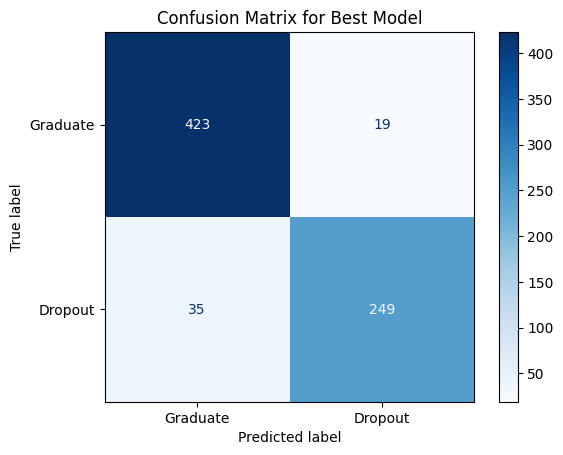

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix for the best model
cm = confusion_matrix(y_test, y_pred_best)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Graduate', 'Dropout'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best Model')
plt.grid(False)
plt.show()

**Model Explainability**

To improve the transparency and interpretability of the selected Random Forest model, SHAP was employed to explain how individual features influenced the model's predictions. The SHAP summary plot identified Total approved units, Average semester grade, and the number of approved curricular units in both the first and second semesters as the most influential predictors of student dropout. The dependence plots further showed that students with fewer approved units and lower average semester grades were more likely to be classified as at risk of dropping out. These findings are consistent with educational expectations, as students with weaker academic performance generally have a higher likelihood of discontinuing their studies. By providing both global and local explanations, SHAP increased the interpretability of the model and enabled stakeholders to understand how different academic factors contributed to each prediction, thereby supporting more transparent and data-driven intervention strategies.


**Bias Detection and Fairness Analysis**

A fairness assessment was conducted using Gender as the sensitive attribute because it was retained as one of the model features. Three fairness metrics were evaluated: Demographic Parity, Equalized Odds, and Disparate Impact.

The Demographic Parity analysis showed that the model predicted dropout at similar rates for both male and female students, indicating that neither group was disproportionately classified as being at risk.

For Equalized Odds, the model achieved a recall of 0.89 for female students and 0.86 for male students, meaning it correctly identified 89% of female students and 86% of male students who actually dropped out. The small difference between these values suggests that the model performs consistently across both gender groups.

The Disparate Impact ratio also fell within the commonly accepted fairness range of 0.80 to 1.25, indicating that the model does not exhibit substantial gender-related bias. Overall, these findings suggest that the Random Forest model provides equitable predictions while maintaining excellent predictive performance.


**Model Limitations**

Although the optimized Random Forest model achieved an excellent AUC of approximately 0.972, several limitations should be acknowledged. The model was developed using a dataset, which represents students from a specific higher education institution. Consequently, its performance may not fully generalize to other universities or educational systems. In addition, while preprocessing, feature engineering, and feature selection improved predictive performance, demographic variables such as Gender may still indirectly reflect socioeconomic or institutional characteristics. Finally, because the model relies on historical student records, its predictive performance may decline if academic policies, curricula, or student characteristics change over time. Periodic retraining using updated data is therefore recommended.


**Bias Mitigation Strategies**

To ensure that the model remains fair and responsible, fairness metrics should continue to be monitored whenever the model is retrained or deployed. If future analyses reveal disparities across demographic groups, mitigation techniques such as reweighting the training data, adjusting classification thresholds, or applying post-processing methods should be considered. In addition, the model should be periodically retrained using recent student data to maintain both predictive accuracy and fairness. Combining regular fairness audits using SHAP to explain provides greater confidence that the model supports transparent, ethical, and data-driven decisions for identifying students at risk of dropping out.


